# Chemical space - visualization
MDS is computationally too expensive (because of the distance matrix).

Therefore, we will use UMAP (umap learn) and t-SNE (scikit learn).

We will visualize the sources <-- ECFP <-- RDKitMol.

In [13]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# 1. Load the dataframe
df = pd.read_csv('../my_data/structures_best.csv')

# 2. Create the rdmol column (RDKit Molecule objects)
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 3. Create RDKit molecule objects
df['rdmol'] = df['Canonical_SMILES'].apply(Chem.MolFromSmiles)

# 4. Generate ECFP fingerprints using GetFingerprint
# This returns an ExplicitBitVect which we then convert to a string
df['ECFP'] = df['rdmol'].apply(
    lambda m: fp_gen.GetFingerprint(m).ToBitString() if m else None
)

# Preview
print(df[['Canonical_SMILES', 'ECFP']].head())

                                    Canonical_SMILES  \
0  CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...   
1  CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...   
2  N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...   
3  CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...   
4  C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...   

                                                ECFP  
0  0100000000000000000000000000000000000000010000...  
1  0100000000000000000000000000000000000000000000...  
2  0100000000000000000000000000000000000000000000...  
3  0100000000000000000000000000000000000000000000...  
4  0100010000000000000100000000000000000010000000...  


Data shape: (18896, 2048)


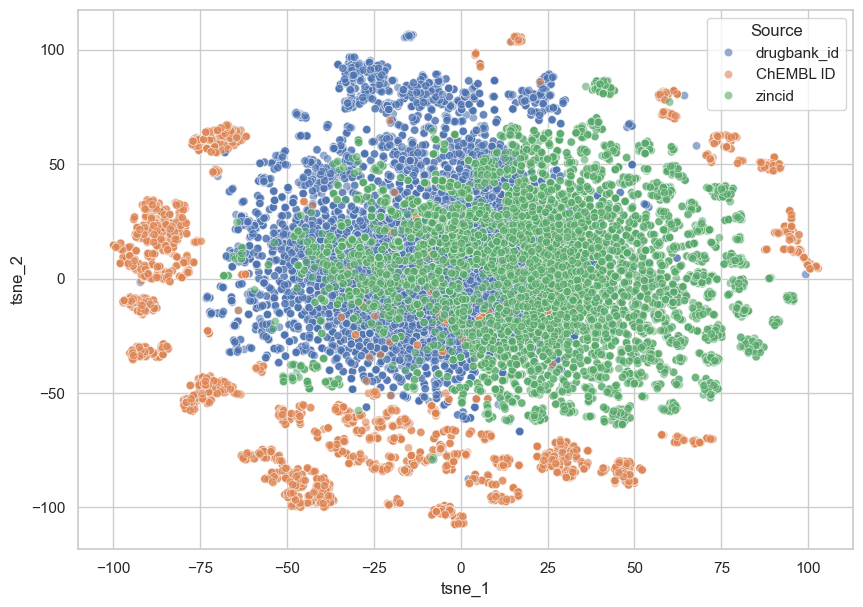

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import seaborn as sns
sns.set_theme(style="whitegrid")

df = df.dropna(subset=['ECFP']).copy()
df['ECFP_list'] = df['ECFP'].apply(lambda x: [int(bit) for bit in x])

# 2. Stack into a 2D matrix
X = np.array(df['ECFP_list'].tolist())

# 3. Check shape (should be (n_samples, 2048))
print(f"Data shape: {X.shape}")

# 4. Run t-SNE
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X)

# 5. Visualize
df['tsne_1'] = X_embedded[:, 0]
df['tsne_2'] = X_embedded[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='tsne_1', y='tsne_2', hue='Source', alpha=0.6)
plt.show()

The default t-SNE uses Euclidean distance, which may not be ideal for binary fingerprints. Let's try using Jaccard distance instead.

C:\Users\souku\PycharmProjects\cdd2026\.venv\Lib\site-packages\sklearn\metrics\pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
C:\Users\souku\PycharmProjects\cdd2026\.venv\Lib\site-packages\sklearn\metrics\pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
C:\Users\souku\PycharmProjects\cdd2026\.venv\Lib\site-packages\sklearn\metrics\pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


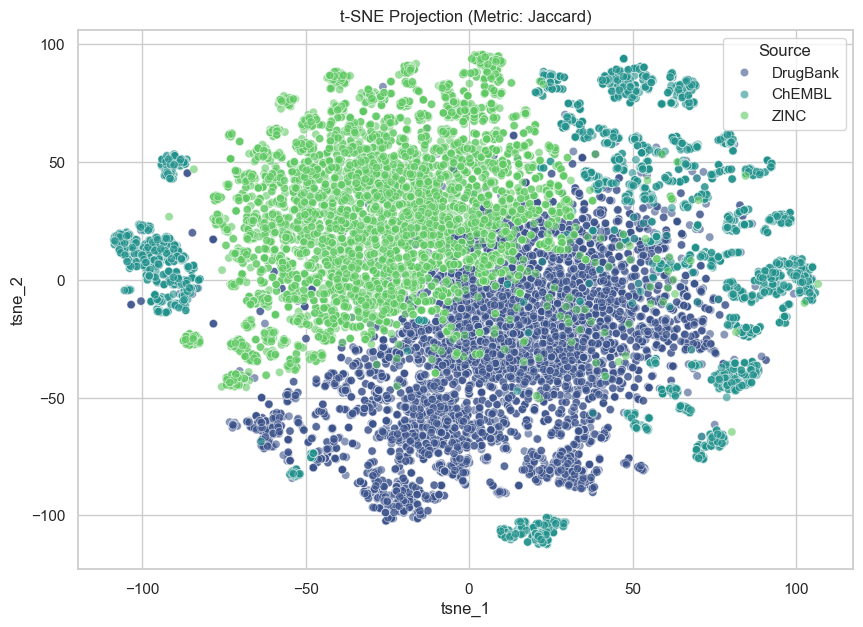

In [34]:
tsne = TSNE(
    n_components=2,
    metric='jaccard',      # Changed from default Euclidean
    init='random',         # 'pca' does not work with non-Euclidean metrics
    random_state=42,
    learning_rate='auto'
)
X_embedded = tsne.fit_transform(X)

df['tsne_1'] = X_embedded[:, 0]
df['tsne_2'] = X_embedded[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='tsne_1',
    y='tsne_2',
    hue='Source',
    palette='viridis',
    alpha=0.6
)
plt.title('t-SNE Projection (Metric: Jaccard)')
plt.show()

Let's perform diversity picking and show the picked molecules on the t-SNE plot.

In [52]:
from rdkit import DataStructs
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

df = df[df["Source"] != "DrugBank"]

picker = MaxMinPicker()
picked_indices = picker.LazyPick(
    lambda i, j: 1.0 - DataStructs.TanimotoSimilarity(
        DataStructs.CreateFromBitString(df['ECFP'].iloc[i]),
        DataStructs.CreateFromBitString(df['ECFP'].iloc[j])
    ),
    len(df),
    50,
    seed=42
)

df['is_picked'] = False
df.iloc[list(picked_indices), df.columns.get_loc('is_picked')] = True

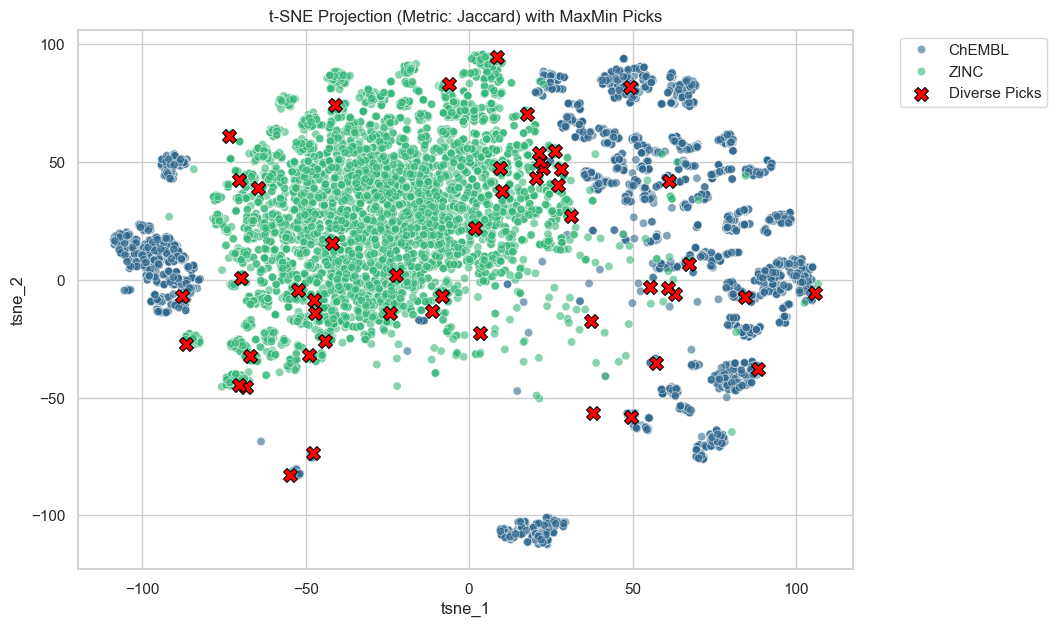

In [53]:
plt.figure(figsize=(10, 7))

# 1. Plot entire dataset with your viridis settings
sns.scatterplot(
    data=df,
    x='tsne_1',
    y='tsne_2',
    hue='Source',
    palette='viridis',
    alpha=0.6,
    zorder=1
)

# 2. Overlay picked molecules as red 'X's
sns.scatterplot(
    data=df[df['is_picked']],
    x='tsne_1',
    y='tsne_2',
    color='red',
    marker='X',
    s=100,
    edgecolor='black',
    zorder=2,
    label='Diverse Picks'
)

plt.title('t-SNE Projection (Metric: Jaccard) with MaxMin Picks')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Data shape for UMAP: (18896, 2048)


C:\Users\souku\PycharmProjects\cdd2026\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


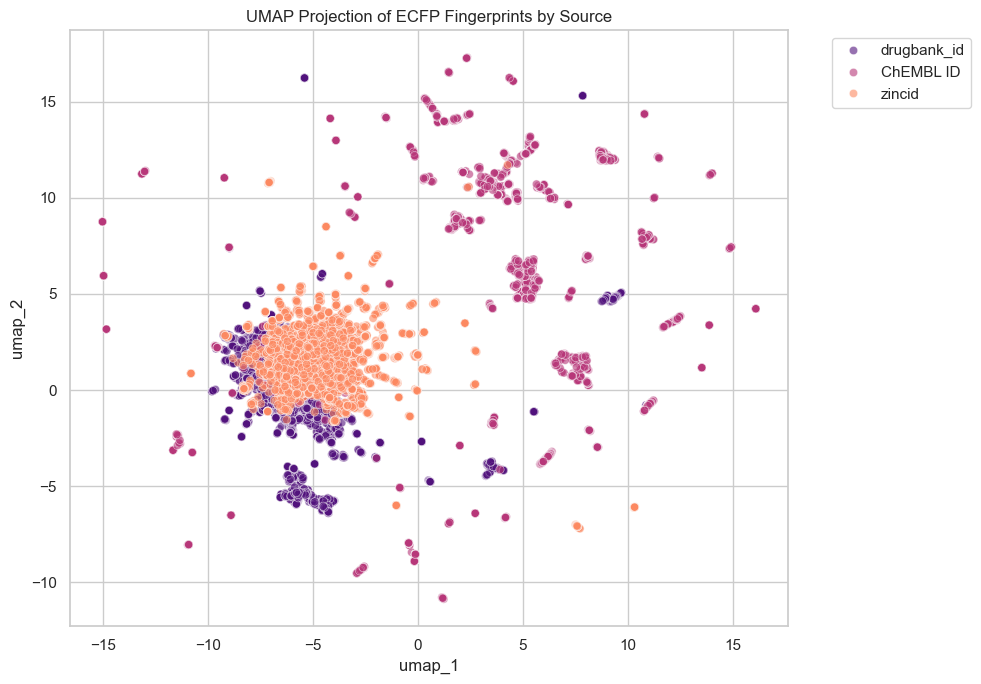

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import umap
sns.set_theme(style="whitegrid")


# 1. Prepare data (Filtering out rows without fingerprints)
df = df.dropna(subset=['ECFP']).copy()
X = np.array([list(map(int, bitstr)) for bitstr in df['ECFP']])

print(f"Data shape for UMAP: {X.shape}")

# 2. Run UMAP
# n_neighbors: controls local vs global structure (usually 5-50)
# min_dist: controls how tightly points are packed (usually 0.001-0.5)
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
X_embedded = reducer.fit_transform(X)

# 3. Add coordinates back to dataframe
df['umap_1'] = X_embedded[:, 0]
df['umap_2'] = X_embedded[:, 1]

# 4. Visualize
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='umap_1',
    y='umap_2',
    hue='Source',
    palette='magma',
    alpha=0.6
)
plt.title('UMAP Projection of ECFP Fingerprints by Source')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Since we added the umap_1 and umap_2 columns directly to our dataframe, every point in the scatter plot corresponds exactly to the molecule in that row. We can now map clusters back to original molecules.

In [22]:
import plotly.express as px

fig = px.scatter(
    df,
    x='umap_1',
    y='umap_2',
    color='Source',
    hover_data=['Canonical_SMILES', 'Source'], # Add any columns you want to see
    title='Interactive UMAP'
)
fig.show()

Let's look for example on the ChEMBL cluster around umap_1 = 5 and umap_2 = 5.

In [28]:
# Isolate a specific cluster by coordinates
cluster_df = df[(df['umap_1'] > 4.5) & (df['umap_1'] < 6) & (df['umap_2'] < 6) & (df['umap_2'] > 5)]

# Display the first few molecules in this cluster
print(cluster_df[['Source', 'Canonical_SMILES']].count())

Source              223
Canonical_SMILES    223
dtype: int64


In this specific cluster are 223 samples. Let's visualize the common substructure:

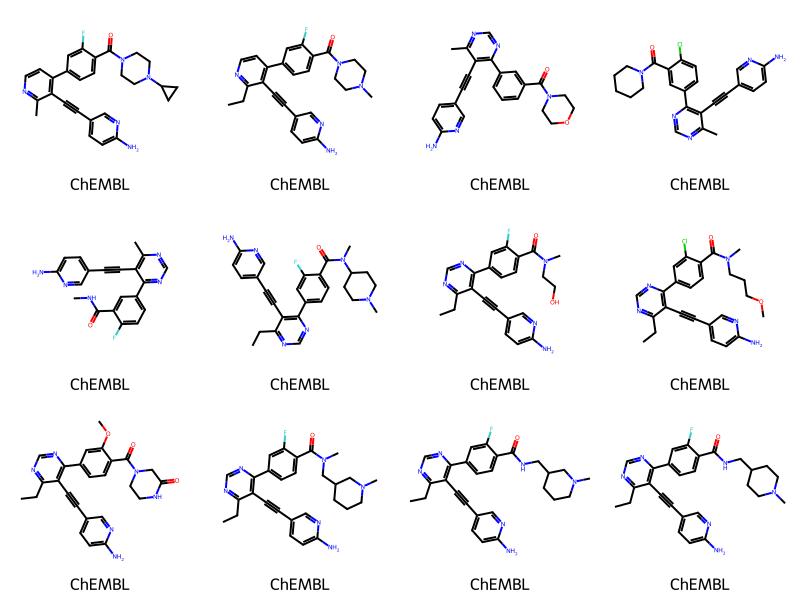

In [29]:
from rdkit.Chem import Draw

# Select top 12 molecules from a specific cluster area
subset = df[(df['umap_1'] > 4.5) & (df['umap_1'] < 6) & (df['umap_2'] < 6) & (df['umap_2'] > 5)].head(12)
mols = [Chem.MolFromSmiles(s) for s in subset['Canonical_SMILES']]

Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), legends=subset['Source'].tolist())

Common Substructure SMARTS: [#6]1:[#6]:[#6](-[#6]:[#6](:[#6](:[#7]:[#6])-[#6])-[#6]#[#6]-[#6]2:[#6]:[#6]:[#6]:[#7]:[#6]:2):[#6]:[#6]:[#6]:1


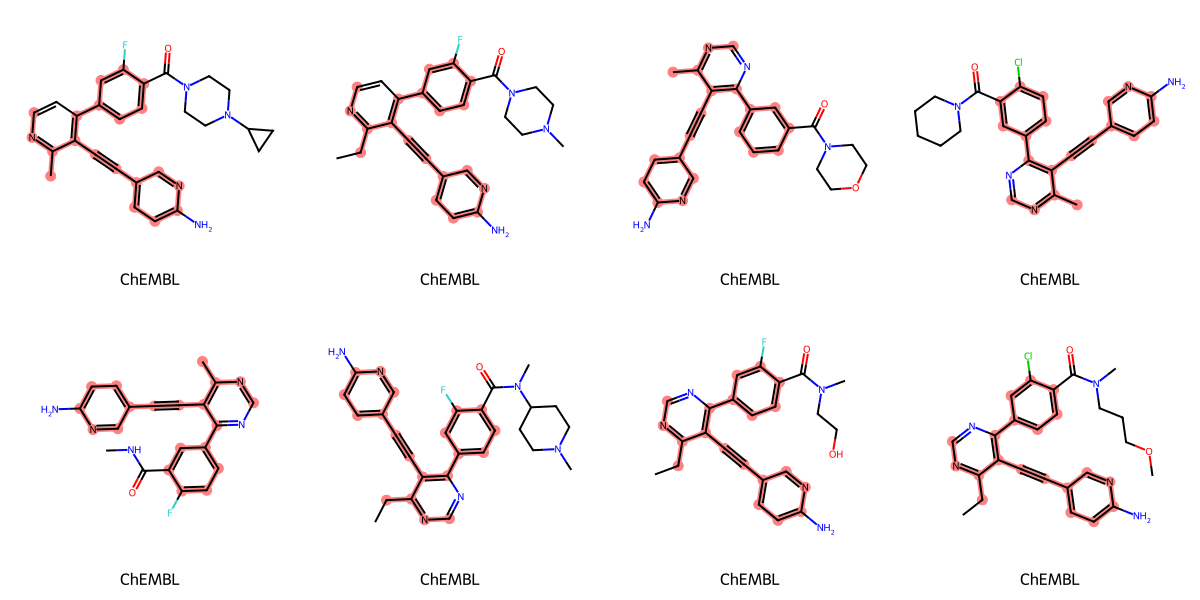

In [32]:
from rdkit.Chem import rdFMCS
from rdkit.Chem import Draw

# 1. Isolate a cluster based on UMAP/t-SNE coordinates
# Adjust these coordinates based on what you see in your plot
cluster_df = df[(df['umap_1'] > 4.5) & (df['umap_1'] < 6) & (df['umap_2'] < 6) & (df['umap_2'] > 5)].copy()

# Convert SMILES to RDKit molecules
cluster_mols = [Chem.MolFromSmiles(s) for s in cluster_df['Canonical_SMILES']]

# 2. Find the Maximum Common Substructure
# timeout=10 prevents it from running forever on very diverse sets
res = rdFMCS.FindMCS(cluster_mols, timeout=10)
common_substructure = Chem.MolFromSmarts(res.smartsString)

# 3. Visualize the molecules with the common core highlighted
# We'll look at the first 8 molecules in the cluster
ms = cluster_mols[:8]
highlite_atoms = [m.GetSubstructMatch(common_substructure) for m in ms]

print(f"Common Substructure SMARTS: {res.smartsString}")
Draw.MolsToGridImage(
    ms,
    highlightAtomLists=highlite_atoms,
    subImgSize=(300, 300),
    molsPerRow=4,
    legends=cluster_df['Source'].iloc[:8].tolist()
)

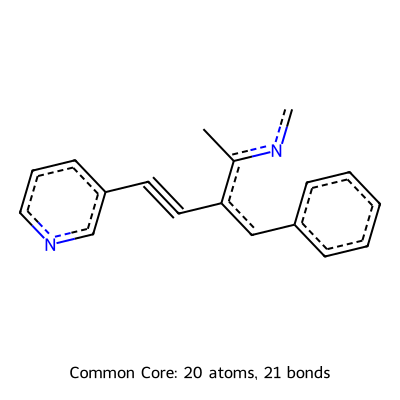

In [33]:
from rdkit import Chem
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import IPythonConsole # For Jupyter display
from rdkit.Chem import Draw

# 1. Get molecules from your cluster
# (Assuming cluster_mols is already defined from the previous step)
res = rdFMCS.FindMCS(cluster_mols, timeout=10)

# 2. Convert the SMARTS result into a drawable Molecule object
common_query = Chem.MolFromSmarts(res.smartsString)

# 3. Draw only the core
if common_query:
    # Set legend to show how many atoms/bonds are in the core
    legend = f"Common Core: {res.numAtoms} atoms, {res.numBonds} bonds"

    # Generate the image
    img = Draw.MolToImage(common_query, size=(400, 400), legend=legend)
    display(img)
else:
    print("No common substructure found.")

Wow, so this is the common substructure for some of the first molecules in this cluster.

In [51]:
# save columns "Canonical_SMILES", "ECFP", "Source", "umap_1", "umap_2", "tsne_1", "tsne_2" to a new csv file
df.to_csv('../my_data/structures_visualization.csv', columns=['Canonical_SMILES', 'ECFP', 'Source', 'umap_1', 'umap_2', 'tsne_1', 'tsne_2'], index=False)